# Esplorazione del dataset catch_me.csv

Caricamento, controllo della qualità, distribuzioni principali e analisi dei dialoghi.

In [1]:
from pathlib import Path
import ast

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 120)
plt.style.use('seaborn-v0_8-whitegrid')

In [18]:
csv_path = Path('catch_me.csv') if Path('catch_me.csv').exists() else Path('Test/catch_me.csv')
df = pd.read_csv(csv_path, encoding='utf-8')
print('File:', csv_path.resolve())
print('Dimensioni:', df.shape)

File: C:\Users\micha\OneDrive\Desktop\Università\Progetti\GBV-CounterSpeech\Test\catch_me.csv
Dimensioni: (2013, 19)


## 1. Prima ispezione

In [19]:
display(df.head(3))
df.info()

,parent,id,task_id,task_name,language,project_id,normalised_document_name,TARGET,URL,CLAIM,nr_turns,nr_cs,flat_url,doc_id,file_id,annotation_strategy,permanent_url,annotations,original_dialogue
0,0,249,1020,Task - disability_benefit_transition_pip_vs_dla.txt,en,22,['disability_benefit_transition_pip_vs_dla.txt'],['DISABLED'],['https://fullfact.org/economy/are-people-mental-health-conditions-now-receiving-higher-disability-benefit-payments/'],['More people are eligible for support under PIP than DLA.'],6,3,['https://fullfact.org/economy/are-people-mental-health-conditions-now-receiving-higher-disability-benefit-payments/'],[1],[1052],Interactive,['https://web.archive.org/web/20170714012600/https://fullfact.org/economy/are-people-mental-health-conditions-now-re...,"{'data': [{'speaker': 'speaker_1', 'text': 'People claiming PIP for mental illness are just trying to scam the syste...","[{'speaker': 'speaker_1', 'text': 'People claiming PIP for mental health conditions are just trying to scam the syst..."
1,0,250,1021,Task - factchecking_claims_about_benefits_discrepancies.txt,en,22,['factchecking_claims_about_benefits_discrepancies.txt'],['MIGRANTS'],['https://fullfact.org/immigration/pensioners-or-refugees/'],"['Illegal immigrants or refugees living in Britain get a total yearly benefit of £29,900.']",6,3,['https://fullfact.org/immigration/pensioners-or-refugees/'],[2],[1053],Interactive,['http://web.archive.org/web/20260321105313/https://fullfact.org/immigration/pensioners-or-refugees/'],"{'data': [{'speaker': 'speaker_1', 'text': ""Did you know that illegal immigrants are taking more benefits than hard-...","[{'speaker': 'speaker_1', 'text': ''}, {'speaker': 'speaker_2', 'text': '', 'file_id': [1053]}, {'speaker': 'speaker..."
2,0,251,1022,Task - uk_minimum_income_requirement_for_partners.txt,en,22,['uk_minimum_income_requirement_for_partners.txt'],['MIGRANTS'],['https://fullfact.org/education/you-usually-need-earn-18600-year-bring-non-eu-partner-uk/'],"['If you want to marry and bring in someone from a country outside of the EU, you have to have a salary of over £18,...",6,3,['https://fullfact.org/education/you-usually-need-earn-18600-year-bring-non-eu-partner-uk/'],[3],[1054],Interactive,['https://web.archive.org/web/20180628211018/https://fullfact.org/education/you-usually-need-earn-18600-year-bring-n...,"{'data': [{'speaker': 'speaker_1', 'text': ""I'm glad the UK finally set a minimum income for people coming in! We do...","[{'speaker': 'speaker_1', 'text': ''}, {'speaker': 'speaker_2', 'text': ""While the £18,600 threshold is indeed a mea..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2013 entries, 0 to 2012
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   parent                    2013 non-null   int64 
 1   id                        2013 non-null   int64 
 2   task_id                   2013 non-null   int64 
 3   task_name                 2013 non-null   object
 4   language                  2013 non-null   object
 5   project_id                2013 non-null   int64 
 6   normalised_document_name  2013 non-null   object
 7   TARGET                    2013 non-null   object
 8   URL                       2013 non-null   object
 9   CLAIM                     2013 non-null   object
 10  nr_turns                  2013 non-null   int64 
 11  nr_cs                     2013 non-null   int64 
 12  flat_url                  2013 non-null   object
 13  doc_id                    2013 non-null   object
 14  file_id                 

In [4]:
schema = pd.DataFrame({
    'tipo': df.dtypes.astype(str),
    'non_nulli': df.notna().sum(),
    'mancanti': df.isna().sum(),
    '%_mancanti': (df.isna().mean() * 100).round(2),
    'valori_unici': df.nunique(dropna=True),
})
display(schema)

,tipo,non_nulli,mancanti,%_mancanti,valori_unici
parent,int64,2013,0,0.00,106
id,int64,2013,0,0.00,2013
task_id,int64,2013,0,0.00,2001
task_name,object,2013,0,0.00,874
language,object,2013,0,0.00,5
project_id,int64,2013,0,0.00,20
normalised_document_name,object,2013,0,0.00,828
TARGET,object,2013,0,0.00,22
URL,object,2013,0,0.00,807
CLAIM,object,2013,0,0.00,864


## 2. Qualità e statistiche descrittive

In [5]:
display(df.duplicated().sum())
display(df['id'].duplicated().sum())

0

0

In [6]:
display(df.isna().sum().sort_values(ascending=False).to_frame('mancanti'))
display(df.select_dtypes(include='number').describe().T)

,mancanti
original_dialogue,171
nr_turns,0
annotations,0
permanent_url,0
annotation_strategy,0
file_id,0
doc_id,0
flat_url,0
nr_cs,0
parent,0


,count,mean,std,min,25%,50%,75%,max
parent,2013.0,95.673621,449.395873,0.0,0.0,0.0,0.0,3147.0
id,2013.0,1914.492300,955.340204,249.0,1106.0,1638.0,2881.0,3424.0
task_id,2013.0,2631.322404,970.863065,909.0,1781.0,2364.0,3634.0,4195.0
project_id,2013.0,32.023348,8.893391,20.0,27.0,29.0,39.0,50.0
nr_turns,2013.0,6.109290,1.580818,0.0,6.0,6.0,6.0,17.0
nr_cs,2013.0,3.046200,0.821161,0.0,3.0,3.0,3.0,8.0


## 3. Distribuzioni principali

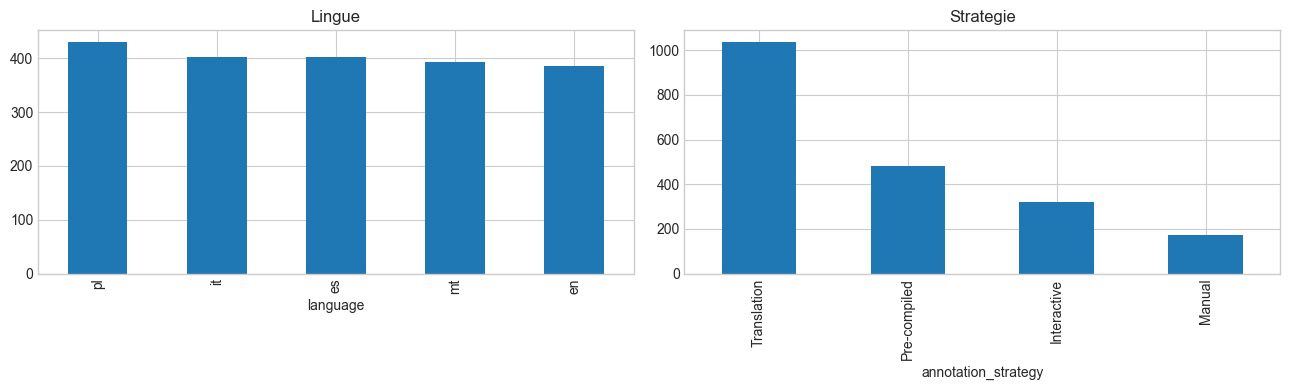

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df['language'].value_counts().plot.bar(ax=axes[0], title='Lingue')
df['annotation_strategy'].value_counts().plot.bar(ax=axes[1], title='Strategie')
plt.tight_layout()
plt.show()

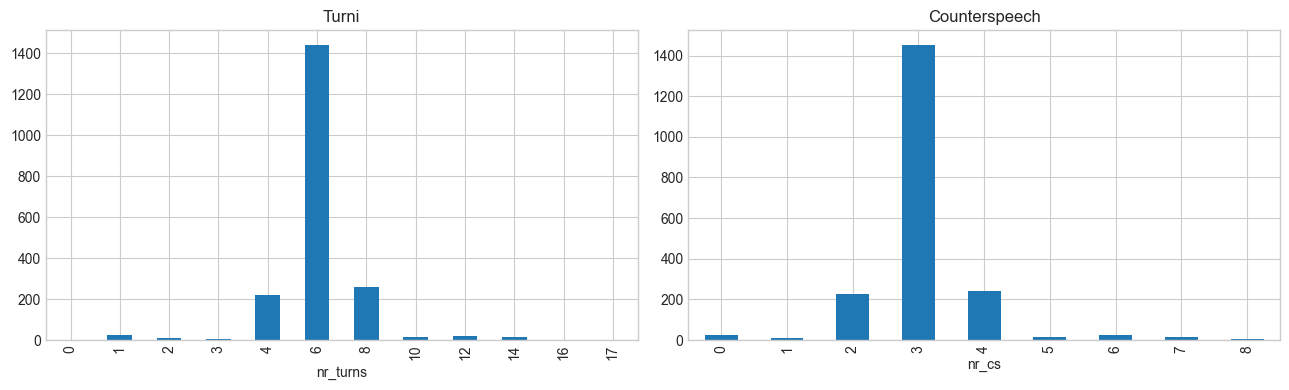

annotation_strategy,Interactive,Manual,Pre-compiled,Translation,All
language,,,,,
en,10,89,287,0,386
es,83,25,50,244,402
it,85,25,48,244,402
mt,30,7,50,306,393
pl,114,25,48,243,430
All,322,171,483,1037,2013


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df['nr_turns'].value_counts().sort_index().plot.bar(ax=axes[0], title='Turni')
df['nr_cs'].value_counts().sort_index().plot.bar(ax=axes[1], title='Counterspeech')
plt.tight_layout()
plt.show()
display(pd.crosstab(df['language'], df['annotation_strategy'], margins=True))

## 4. Parsing delle colonne strutturate

Liste e dizionari sono salvati come testo. ast.literal_eval li converte in oggetti Python in modo sicuro.

In [9]:
def parse_literal(value):
    if pd.isna(value):
        return None
    try:
        return ast.literal_eval(value)
    except (ValueError, SyntaxError, TypeError):
        return None

In [10]:
parsed = df.copy()
for column in ['TARGET', 'annotations', 'original_dialogue']:
    parsed[column + '_parsed'] = parsed[column].map(parse_literal)

display(parsed[['TARGET_parsed', 'annotations_parsed', 'original_dialogue_parsed']].head(3))

,TARGET_parsed,annotations_parsed,original_dialogue_parsed
0,[DISABLED],"{'data': [{'speaker': 'speaker_1', 'text': 'People claiming PIP for mental illness are just trying to scam the syste...","[{'speaker': 'speaker_1', 'text': 'People claiming PIP for mental health conditions are just trying to scam the syst..."
1,[MIGRANTS],"{'data': [{'speaker': 'speaker_1', 'text': 'Did you know that illegal immigrants are taking more benefits than hard-...","[{'speaker': 'speaker_1', 'text': ''}, {'speaker': 'speaker_2', 'text': '', 'file_id': [1053]}, {'speaker': 'speaker..."
2,[MIGRANTS],"{'data': [{'speaker': 'speaker_1', 'text': 'I'm glad the UK finally set a minimum income for people coming in! We do...","[{'speaker': 'speaker_1', 'text': ''}, {'speaker': 'speaker_2', 'text': 'While the £18,600 threshold is indeed a mea..."


In [11]:
target_counts = parsed['TARGET_parsed'].dropna().explode().value_counts()
display(target_counts.to_frame('frequenza'))

,frequenza
TARGET_parsed,
MIGRANTS,624
MUSLIMS,387
WOMEN,339
LGBT+,271
POC,224
DISABLED,145
JEWS,45
"WOMEN, LGBT+",5
"MUSLIMS, WOMEN",5


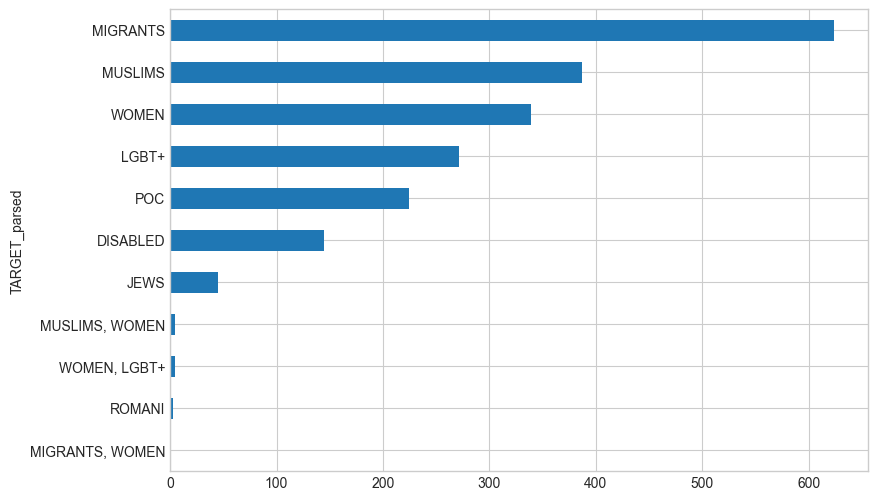

In [12]:
target_counts.sort_values().plot.barh(figsize=(9, 6))
plt.show()

## 5. Dialoghi in formato long (un turno per riga)

In [13]:
turns_base = parsed[['id', 'language', 'TARGET_parsed', 'annotations_parsed']].copy()
turns_base['turn'] = turns_base['annotations_parsed'].map(
    lambda x: x.get('data', []) if isinstance(x, dict) else []
)
turns_base = turns_base.explode('turn').dropna(subset=['turn']).reset_index(drop=True)

In [14]:
details = pd.json_normalize(turns_base['turn'])
turns_df = pd.concat([turns_base.drop(columns=['turn', 'annotations_parsed']), details], axis=1)
turns_df['turn_number'] = turns_df.groupby('id').cumcount() + 1
turns_df['text_length'] = turns_df['text'].fillna('').str.len()
display(turns_df.head(10))

,id,language,TARGET_parsed,speaker,text,file_id,turn_number,text_length
0,249,en,[DISABLED],speaker_1,"People claiming PIP for mental illness are just trying to scam the system for more money, and it’s unfair to those w...",NaN,1,135
1,249,en,[DISABLED],speaker_2,It's important to recognize that the majority of individuals claiming PIP for mental health conditions genuinely nee...,[1052],2,387
2,249,en,[DISABLED],speaker_1,"Oh please, that's just a convenient excuse for laziness. If they truly had issues, they wouldn't be relying on taxpa...",NaN,3,131
3,249,en,[DISABLED],speaker_2,You need to understand that many individuals with mental health issues face significant challenges that can impact t...,[1052],4,399
4,249,en,[DISABLED],speaker_1,The government is wasting money on these people. They need to toughen up and stop playing the victim card for sympathy!,NaN,5,119
5,249,en,[DISABLED],speaker_2,"Keep in mind that these individuals have been facing significant difficulties for a long time, with expectations for...",[1052],6,361
6,250,en,[MIGRANTS],speaker_1,Did you know that illegal immigrants are taking more benefits than hard-working British pensioners? It's outrageous!,NaN,1,116
7,250,en,[MIGRANTS],speaker_2,"This claim is misleading. In reality, most illegal immigrants do not have access to welfare benefits, and the figure...",[1053],2,242
8,250,en,[MIGRANTS],speaker_1,Of course they have access to benefits! Why else would they risk coming here illegally?,NaN,3,88
9,250,en,[MIGRANTS],speaker_2,"Actually, asylum seekers are not allowed to claim social security benefits while they await a decision on their stat...",[1053],4,334


In [15]:
display(
    turns_df.groupby(['language', 'speaker'])['text_length']
            .agg(['count', 'mean', 'median', 'max']).round(1)
)

count   mean  median   max
language speaker                              
en       speaker_1   1208  104.8   104.0   381
         speaker_2   1204  234.9   246.0   470
es       speaker_1   1200  112.7   111.0   407
         speaker_2   1197  245.3   254.0   549
it       speaker_1   1158  109.3   108.0   437
         speaker_2   1158  255.3   263.0   612
mt       speaker_1   1143  120.4   117.0   417
         speaker_2   1116  267.8   276.0   597
pl       speaker_1   1457  109.6   105.0   409
         speaker_2   1457  273.1   256.0  1108

## 6. Consultare e cercare esempi

In [16]:
# Cambia sample_id per visualizzare un altro dialogo.
sample_id = df.iloc[0]['id']
sample = turns_df.loc[turns_df['id'] == sample_id]
display(sample[['turn_number', 'speaker', 'text']])

,turn_number,speaker,text
0,1,speaker_1,"People claiming PIP for mental illness are just trying to scam the system for more money, and it’s unfair to those w..."
1,2,speaker_2,It's important to recognize that the majority of individuals claiming PIP for mental health conditions genuinely nee...
2,3,speaker_1,"Oh please, that's just a convenient excuse for laziness. If they truly had issues, they wouldn't be relying on taxpa..."
3,4,speaker_2,You need to understand that many individuals with mental health issues face significant challenges that can impact t...
4,5,speaker_1,The government is wasting money on these people. They need to toughen up and stop playing the victim card for sympathy!
5,6,speaker_2,"Keep in mind that these individuals have been facing significant difficulties for a long time, with expectations for..."


In [17]:
# Ricerca case-insensitive; cambia query liberamente.
query = 'benefit'
matches = turns_df['text'].fillna('').str.contains(query, case=False, regex=False)
display(turns_df.loc[matches, ['id', 'language', 'TARGET_parsed', 'speaker', 'text']].head(20))

,id,language,TARGET_parsed,speaker,text
3,249,en,[DISABLED],speaker_2,You need to understand that many individuals with mental health issues face significant challenges that can impact t...
6,250,en,[MIGRANTS],speaker_1,Did you know that illegal immigrants are taking more benefits than hard-working British pensioners? It's outrageous!
7,250,en,[MIGRANTS],speaker_2,"This claim is misleading. In reality, most illegal immigrants do not have access to welfare benefits, and the figure..."
8,250,en,[MIGRANTS],speaker_1,Of course they have access to benefits! Why else would they risk coming here illegally?
9,250,en,[MIGRANTS],speaker_2,"Actually, asylum seekers are not allowed to claim social security benefits while they await a decision on their stat..."
11,250,en,[MIGRANTS],speaker_2,"As I told you, they are not eligible for benefits such as jobseeker's or employment and support allowance, as establ..."
13,251,en,[MIGRANTS],speaker_2,"While the £18,600 threshold is indeed a measure to control specific benefits, it's also crucial to consider the dive..."
23,252,en,[DISABLED],speaker_2,"Companies are just adapting to a more inclusive workforce, which benefits everyone. Rather than turning everything i..."
30,254,en,[MIGRANTS],speaker_1,It's unbelievable that illegal immigrants and refugees are getting more benefits than our hard-working pensioners! T...
31,254,en,[MIGRANTS],speaker_2,"I understand were you're coming from, but it's important to note that illegal immigrants are not entitled to benefit..."
